In [ ]:
%matplotlib inline

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np  

import statsmodels
import statsmodels.api as sm
from statsmodels.formula.api import ols

import scipy.stats as stats

# Hypothesis Testing Exercise: Part 1
## Comparing Distributions. Testing statistical hypotheses. p-value. Goodness of fit

### Problem 1. t-test
You're given a dataset which describes the age at death among members of the sovereignty, aristocracy, and gentry. There is an explanation [here](http://www.stat.ufl.edu/~winner/data/agedeath.txt) and the actual data is [here](http://www.stat.ufl.edu/~winner/data/agedeath.dat). Get to know the data; plot histograms and / or boxplots, or other graphs as needed. Note that all ages are only for a certain social class of people and they won't represent the entire population of people.

Do the mean ages differ significantly ($\alpha = 5\%$)? Perform a t-test. Do you need an independent or paired test?

In [6]:
horse_beginners = pd.read_fwf('Data/horse_beginners.dat')
horse_beginners = horse_beginners.drop(columns=['Unnamed: 0'])

In [7]:
horse_beginners

,Subject,Actual,Imaginary
0,S1,69.64,66.58
1,S2,62.26,25.59
2,S3,78.63,24.01
3,S4,76.00,38.35
4,S5,60.10,12.19
5,S6,68.51,34.25
6,S7,69.57,5.68
7,S8,74.48,15.02


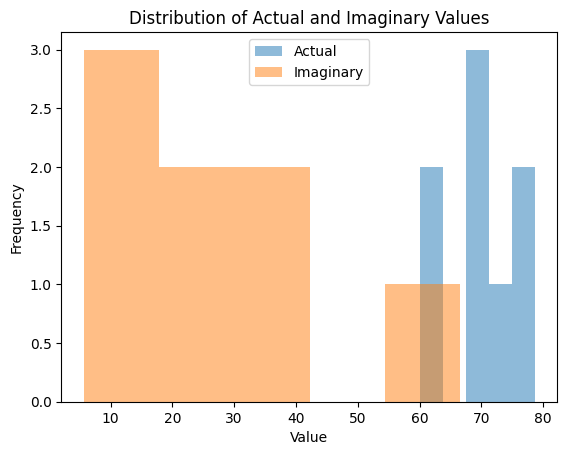

In [9]:
plt.hist(horse_beginners.Actual, bins=5, alpha=0.5, label='Actual')
plt.hist(horse_beginners.Imaginary, bins=5, alpha=0.5, label='Imaginary')
plt.legend()
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Distribution of Actual and Imaginary Values')
plt.show()

In [11]:
stats.ttest_rel(horse_beginners.Actual, horse_beginners.Imaginary)

TtestResult(statistic=np.float64(6.190025790155937), pvalue=np.float64(0.00044960248190267684), df=np.int64(7))

In [12]:
horse_beginners[['Actual', 'Imaginary']].mean()

Actual       69.89875
Imaginary    27.70875
dtype: float64

In [13]:
horse_beginners.describe().T

,count,mean,std,min,25%,50%,75%,max
Actual,8.0,69.89875,6.446677,60.10,66.9475,69.605,74.860,78.63
Imaginary,8.0,27.70875,19.169432,5.68,14.3125,24.800,35.275,66.58


In [14]:
stats.ttest_rel(horse_beginners.drop(6).Actual, horse_beginners.drop(6).Imaginary)

TtestResult(statistic=np.float64(5.5770683788392175), pvalue=np.float64(0.0014103588659258076), df=np.int64(6))

Let's try something else. In the `data/horse_beginners.dat` file, there's data about 8 people. Each person is a beginner in horse riding. They were asked to imagine how long their ride would take (for a fixed track length). After that, the actual times were measured.

Get acquainted with the data and draw some plots if you need (hint: boxplots are useful for comparing distributions). Are the people good at predicting their ride times? That is, are there significant differences between imagined and actual time (5%-level)? Also, is the imagined time **significantly longer** than the real time? Perform a t-test. Don't forget that the subjects are the same.

In [2]:
# Write your code here

### Problem 2. ANOVA
Read [this](http://www.itl.nist.gov/div898/education/anova/newcar.dat) dataset. Get acquainted with it and plot graphics. Note that it's formatted a bit oddly. First, you have to skip some rows; second, the target variable is first (in most datasets, it's the last one). Well, that shouldn't bother you :).

Do the rates differ significantly ($\alpha = 0,05$) between cities? Apply one-way ANOVA to find out.

**Hint:** You have to group all values by city. You can get a dictionary of groups like this:
```python
groups = { k: v.tolist() for k, v in cars.groupby("City").Rate }
```

After that, you can use ```*groups.values()``` to pass all dictionary values as separate arguments to a function.

In [16]:
rats = pd.read_fwf('Data/ratfeed.dat', skiprows=25, header=None)
rats.columns = ['Weight', 'Amount', 'Diet']

In [17]:
rats

,Weight,Amount,Diet
0,118,1,1
1,117,1,1
2,111,1,1
3,107,1,1
4,104,1,1
5,102,1,1
6,100,1,1
7,87,1,1
8,81,1,1
9,73,1,1


In [18]:
rats.describe().T

,count,mean,std,min,25%,50%,75%,max
Weight,60.0,87.866667,16.569798,49.0,76.75,89.5,98.5,120.0
Amount,60.0,1.500000,0.504219,1.0,1.00,1.5,2.0,2.0
Diet,60.0,2.000000,0.823387,1.0,1.00,2.0,3.0,3.0


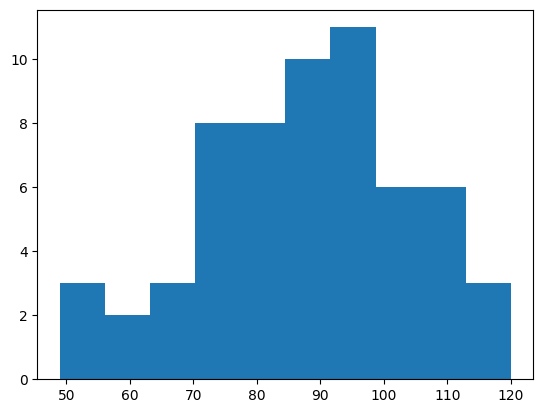

In [19]:
plt.hist(rats.Weight)
plt.show()

In [20]:
high_amount = rats[rats.Amount == 1]
low_amount = rats[rats.Amount == 2]

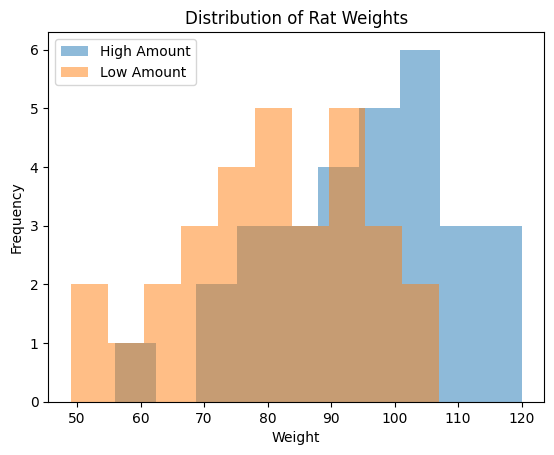

In [22]:
plt.hist(high_amount.Weight, alpha=0.5, label='High Amount')
plt.hist(low_amount.Weight, alpha=0.5, label='Low Amount')
plt.xlabel('Weight')
plt.ylabel('Frequency')
plt.title('Distribution of Rat Weights')
plt.legend()
plt.show()

In [23]:
beef = rats[rats.Diet == 1]
pork = rats[rats.Diet == 2]
cereal = rats[rats.Diet == 3]   

(array([2., 0., 1., 4., 2., 2., 2., 5., 0., 2.]),
 array([ 56. ,  61.5,  67. ,  72.5,  78. ,  83.5,  89. ,  94.5, 100. ,
        105.5, 111. ]),
 <BarContainer object of 10 artists>)

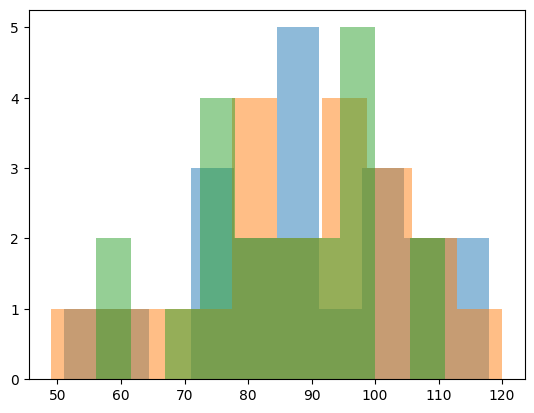

In [25]:
plt.hist(beef.Weight, alpha=0.5, label='Beef')
plt.hist(pork.Weight, alpha=0.5, label='Pork')
plt.hist(cereal.Weight, alpha=0.5, label='Cereal')

In [28]:
stats.f_oneway(beef.Weight, pork.Weight, cereal.Weight)

F_onewayResult(statistic=np.float64(0.47677688232783516), pvalue=np.float64(0.6232342640383874))

In [29]:
stats.f_oneway(high_amount.Weight, low_amount.Weight)

F_onewayResult(statistic=np.float64(14.102077151335314), pvalue=np.float64(0.0004033228303676357))

In [30]:
rats.Weight * rats.Diet

0     118
1     117
2     111
3     107
4     104
5     102
6     100
7      87
8      81
9      73
10    240
11    216
12    210
13    204
14    204
15    196
16    192
17    188
18    182
19    158
20    333
21    294
22    285
23    276
24    264
25    258
26    246
27    231
28    222
29    168
30     95
31     90
32     90
33     90
34     86
35     78
36     76
37     72
38     64
39     51
40    212
41    194
42    172
43    164
44    164
45    162
46    146
47    140
48    122
49     98
50    321
51    294
52    291
53    285
54    267
55    240
56    222
57    222
58    201
59    174
dtype: int64

In [31]:
rats['Combined'] = rats.Weight * rats.Diet

In [35]:
groups = []
for combined_value, group_data in  rats.groupby('Combined'):
    groups.append(group_data.Weight.values)
   

In [36]:
groups

[array([51]),
 array([64]),
 array([72]),
 array([73]),
 array([76]),
 array([78]),
 array([81]),
 array([86]),
 array([87]),
 array([90, 90, 90]),
 array([95]),
 array([49]),
 array([100]),
 array([102]),
 array([104]),
 array([107]),
 array([111]),
 array([117]),
 array([118]),
 array([61]),
 array([70]),
 array([73]),
 array([79]),
 array([81]),
 array([82, 82]),
 array([56]),
 array([86]),
 array([58]),
 array([91]),
 array([94]),
 array([96]),
 array([97]),
 array([98]),
 array([67]),
 array([102, 102]),
 array([105]),
 array([106]),
 array([108]),
 array([74, 74, 74]),
 array([77]),
 array([120,  80]),
 array([82]),
 array([86]),
 array([88]),
 array([89]),
 array([92]),
 array([95, 95]),
 array([97]),
 array([98, 98]),
 array([107]),
 array([111])]

In [37]:
stats.f_oneway(*groups)

F_onewayResult(statistic=np.float64(3.4647599999999996), pvalue=np.float64(0.02517384773397708))

In [38]:
for g, group in rats.groupby(['Amount', 'Diet']):
   print(f'Group: {g}')
    

Group: (1, 1)
Group: (1, 2)
Group: (1, 3)
Group: (2, 1)
Group: (2, 2)
Group: (2, 3)


In [39]:
groups = []
for (amount, diet), group_data in rats.groupby(['Amount', 'Diet']):
    groups.append(group_data.Weight.values)

In [40]:
groups

[array([118, 117, 111, 107, 104, 102, 100,  87,  81,  73]),
 array([120, 108, 105, 102, 102,  98,  96,  94,  91,  79]),
 array([111,  98,  95,  92,  88,  86,  82,  77,  74,  56]),
 array([95, 90, 90, 90, 86, 78, 76, 72, 64, 51]),
 array([106,  97,  86,  82,  82,  81,  73,  70,  61,  49]),
 array([107,  98,  97,  95,  89,  80,  74,  74,  67,  58])]

In [41]:
stats.f_oneway(*groups)

F_onewayResult(statistic=np.float64(4.299989642672192), pvalue=np.float64(0.0022994427341333))

Well, most analyses aren't so simple. Let's have a look at another dataset. This one is located [here](http://www.itl.nist.gov/div898/education/anova/ratfeed.dat). Get acquainted with it.

This time, we've got two explanatory variables: amount and type of diet.

Perform one-way ANOVA to each variable separately, disregarding the other one. 

To do this, take for example the "Amount" variable. Group all weights by amount, disregarding the diet type. Perform ANOVA on the groups, like you did before. Repeat the same process with "Diet".

Do the groups differ significantly at the 5%-level?

In [4]:
# Write your code here

Sometimes we have to take into account multiple values. In this case, we want to ask another question: Is there a significant difference between combinations of diet and amount? These are called **interacting variables**. Unfortunately, there isn't a quick and easy way to perform this test in `scipy.stats`, but `statsmodels` is another library which will come in handy.

We won't go into many details how it works but you basically create a linear model (`ols` stands for "ordinary least squares") and you provide a formula. The formula we want to use looks like this:
```python
formula = "Weight ~ C(Amount) + C(Diet) + C(Amount):C(Diet)"
```

`Weight`, `Amount` and `Diet` are the **column names** (i.e. variable names) in the dataset. `C(Amount)` tells the library to treat the variable as *categorical*, not numerical (e.g. diet 1 + diet 3 makes absolutely no sense). Finally `C(Amount):C(Diet)` means that we take the interaction between these categories (Cartesian product - every amount with every diet).

How do we read this formula? "The Weight column is proportional to the categories Amount, Diet and their interaction" (i.e. Weight is a linear combination of the three other variables).

We are now ready. Well, we could have done all this by hand as well, but why bother :)? Just create the linear model:
```python
model = ols(formula, rats).fit()
```

and the ANOVA table:
```python
table = statsmodels.stats.anova.anova_lm(model, typ = 2)
```

You can see there's "type 2" ANOVA chosen. If you're interested, you can read more about the three types of ANOVA [here](https://mcfromnz.wordpress.com/2011/03/02/anova-type-iiiiii-ss-explained/)

P. S.: The type of formulas we described above are typical for another popular language for statistics and data analysis, called **R**. They're also why many people hate R. They're good but need a bit of understanding and getting accustomed to. Case closed :D.

In [5]:
# Write your code here

### Problem 3. Contingency Tables. $\chi^2$-test
Have a look at the dataset `data/Popular Kids.tsv` and its description `data/Popular Kids Description.txt`.

When we want to compare data across many categories, a useful way we can visualize it, is using **contingency tables** (or two-way tables). One variable goes to the rows, another one - to the columns of the table. The intersection cell represents the number of observations having this combination of values.

Try it now:
```python
pd.crosstab(kids.Grade, kids.Goals)
```

You can also specify multiple columns - this will create higher-dimensional tables. Keep in mind, however, that these are difficult to look at and understand. We're usually fine with two variables, three in some rare cases.

In [43]:
kids = pd.read_table('Data/Popular Kids.tsv')

In [44]:
kids

,Gender,Grade,Age,Race,Urban/Rural,School,Goals,Grades,Sports,Looks,Money
0,boy,5,11,White,Rural,Elm,Sports,1,2,4,3
1,boy,5,10,White,Rural,Elm,Popular,2,1,4,3
2,girl,5,11,White,Rural,Elm,Popular,4,3,1,2
3,girl,5,11,White,Rural,Elm,Popular,2,3,4,1
4,girl,5,10,White,Rural,Elm,Popular,4,2,1,3
...,...,...,...,...,...,...,...,...,...,...,...
473,boy,6,11,White,Urban,Westdale Middle,Grades,4,1,2,3
474,boy,6,11,White,Urban,Westdale Middle,Sports,4,1,2,3
475,boy,6,11,White,Urban,Westdale Middle,Grades,4,2,1,3
476,boy,6,11,White,Urban,Westdale Middle,Popular,4,1,3,2


In [45]:
kids.Grades.value_counts()

Grades
3    133
4    128
2    123
1     94
Name: count, dtype: int64

In [46]:
kids.Goals.value_counts()

Goals
Grades     247
Popular    141
Sports      90
Name: count, dtype: int64

In [51]:
len(kids[
    (kids.Grades == 4) & (kids.Goals == 'Popular')
    ])

49

In [52]:
pd.crosstab(kids.Grades, kids.Goals)

Goals,Grades,Popular,Sports
Grades,,,
1,70,14,10
2,66,33,24
3,55,45,33
4,56,49,23


In [55]:
stats.chi2_contingency(pd.crosstab(kids.Grades, kids.Goals)).expected_freq

array([[48.57322176, 27.72803347, 17.69874477],
       [63.55857741, 36.28242678, 23.15899582],
       [68.72594142, 39.23221757, 25.041841  ],
       [66.14225941, 37.75732218, 24.10041841]])

The **$\chi^2$**-test provides a way to test for association between two (or more) categorical variables. In this case, **Grade** and **Goals** seem to be good candidates. This is most easily done using the contingency table. Fortunately, `scipy.stats` has one such method (read the docs [here](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2_contingency.html)).

Note that this test doesn't specify what the relationship is. It just tells us that there might be a significant relationship.

Are goals related to grade? To what extent? Are these significant?
* $H_0$: No relation between Grade and Goals
* $H_1$: Some relation exists between Grade and Goals
* $\alpha = 0,05$

In [7]:
# Write your code here

The school areas are also divided into "Urban", "Suburban" and "Rural". Are the school areas related to goals? Perform the same type of test. Is the difference significant now?

In [8]:
# Write your code here

Feel free to continue exploring the dataset as you wish. You can find interesting data and relationships. 

**Note:** You'll see the catch of categorical variables - these are very difficult to visualize properly. Most plots just appear as symmetrical patterns of dots. You can rely on contingency tables and correlations to properly describe and explore these variables.